# OSRS NPC Classification -- Challenger Model
# Evaluation

Same eval suite as `04a_eval_champion_local.ipynb`, run against the from-scratch challenger
trained in `03b_train_custom_cnn.ipynb`, on the identical test split. Grad-CAM here targets the
5 conv blocks of the scratch backbone (shallow -> deep) instead of ResNet18's `layer1..layer4`.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from npc_data import load_clean_npc_df, add_top_class_labels, stratified_split, get_transforms, NPCDataset
import eval_utils as eu

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")

Using: cuda


In [2]:
df = load_clean_npc_df(data_dir="../data")
df, CLASS_NAMES, class_to_idx = add_top_class_labels(df, n=10)
train_df, val_df, test_df = stratified_split(df, seed=42)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

_, eval_transform = get_transforms(img_size=128)
test_loader = DataLoader(NPCDataset(test_df, eval_transform, data_dir="../data"), batch_size=32)

Train: 2421 | Val: 519 | Test: 519


In [3]:
def conv_block(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
    )


class ScratchCNNBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
            conv_block(256, 512),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return x.flatten(1)


class ScratchDualCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.chathead_cnn = ScratchCNNBackbone()
        self.body_cnn = ScratchCNNBackbone()
        self.classifier = nn.Sequential(
            nn.Linear(512 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, chathead, body):
        f1 = self.chathead_cnn(chathead)
        f2 = self.body_cnn(body)
        return self.classifier(torch.cat([f1, f2], dim=1))


model = ScratchDualCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)
model.load_state_dict(torch.load("../data/custom_cnn_classifier.pth", map_location=DEVICE))
model.eval()
print("Challenger model loaded.")

Challenger model loaded.


## Classification report

In [4]:
all_labels, all_preds, all_probs = eu.get_predictions(model, test_loader, DEVICE)
eu.print_classification_report(all_labels, all_preds, CLASS_NAMES)

C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


              precision    recall  f1-score   support

       Human       0.87      0.68      0.76       314
       Dwarf       0.38      0.57      0.46        37
         Elf       0.38      0.68      0.48        22
       Gnome       0.55      0.86      0.67        21
     Vampyre       0.75      1.00      0.86         9
       Ghost       0.20      0.12      0.15         8
      Monkey       0.19      0.83      0.30         6
  Dorgeshuun       0.35      1.00      0.52         6
       Troll       0.21      0.80      0.33         5
         Cat       0.18      0.60      0.27         5
       Other       0.53      0.31      0.39        86

    accuracy                           0.62       519
   macro avg       0.42      0.68      0.47       519
weighted avg       0.71      0.62      0.64       519



## Confusion matrix

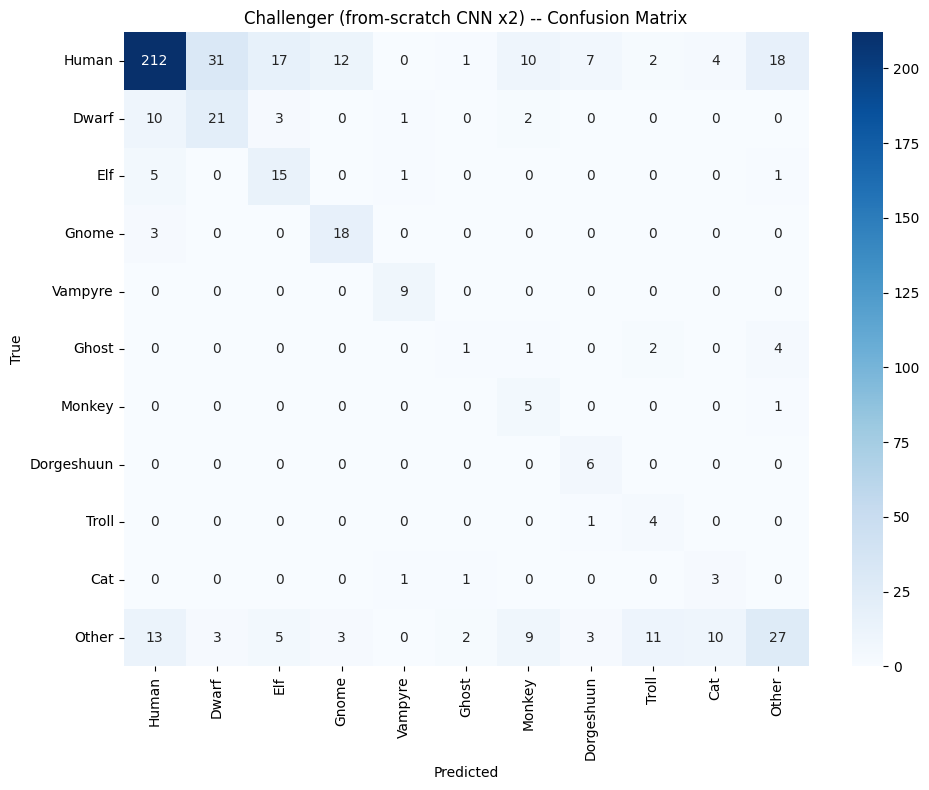

In [5]:
cm_challenger = eu.plot_confusion_matrix(all_labels, all_preds, CLASS_NAMES, title="Challenger (from-scratch CNN x2) -- Confusion Matrix", save_path="../img/challenger_confusion_matrix.png")

## Sample predictions

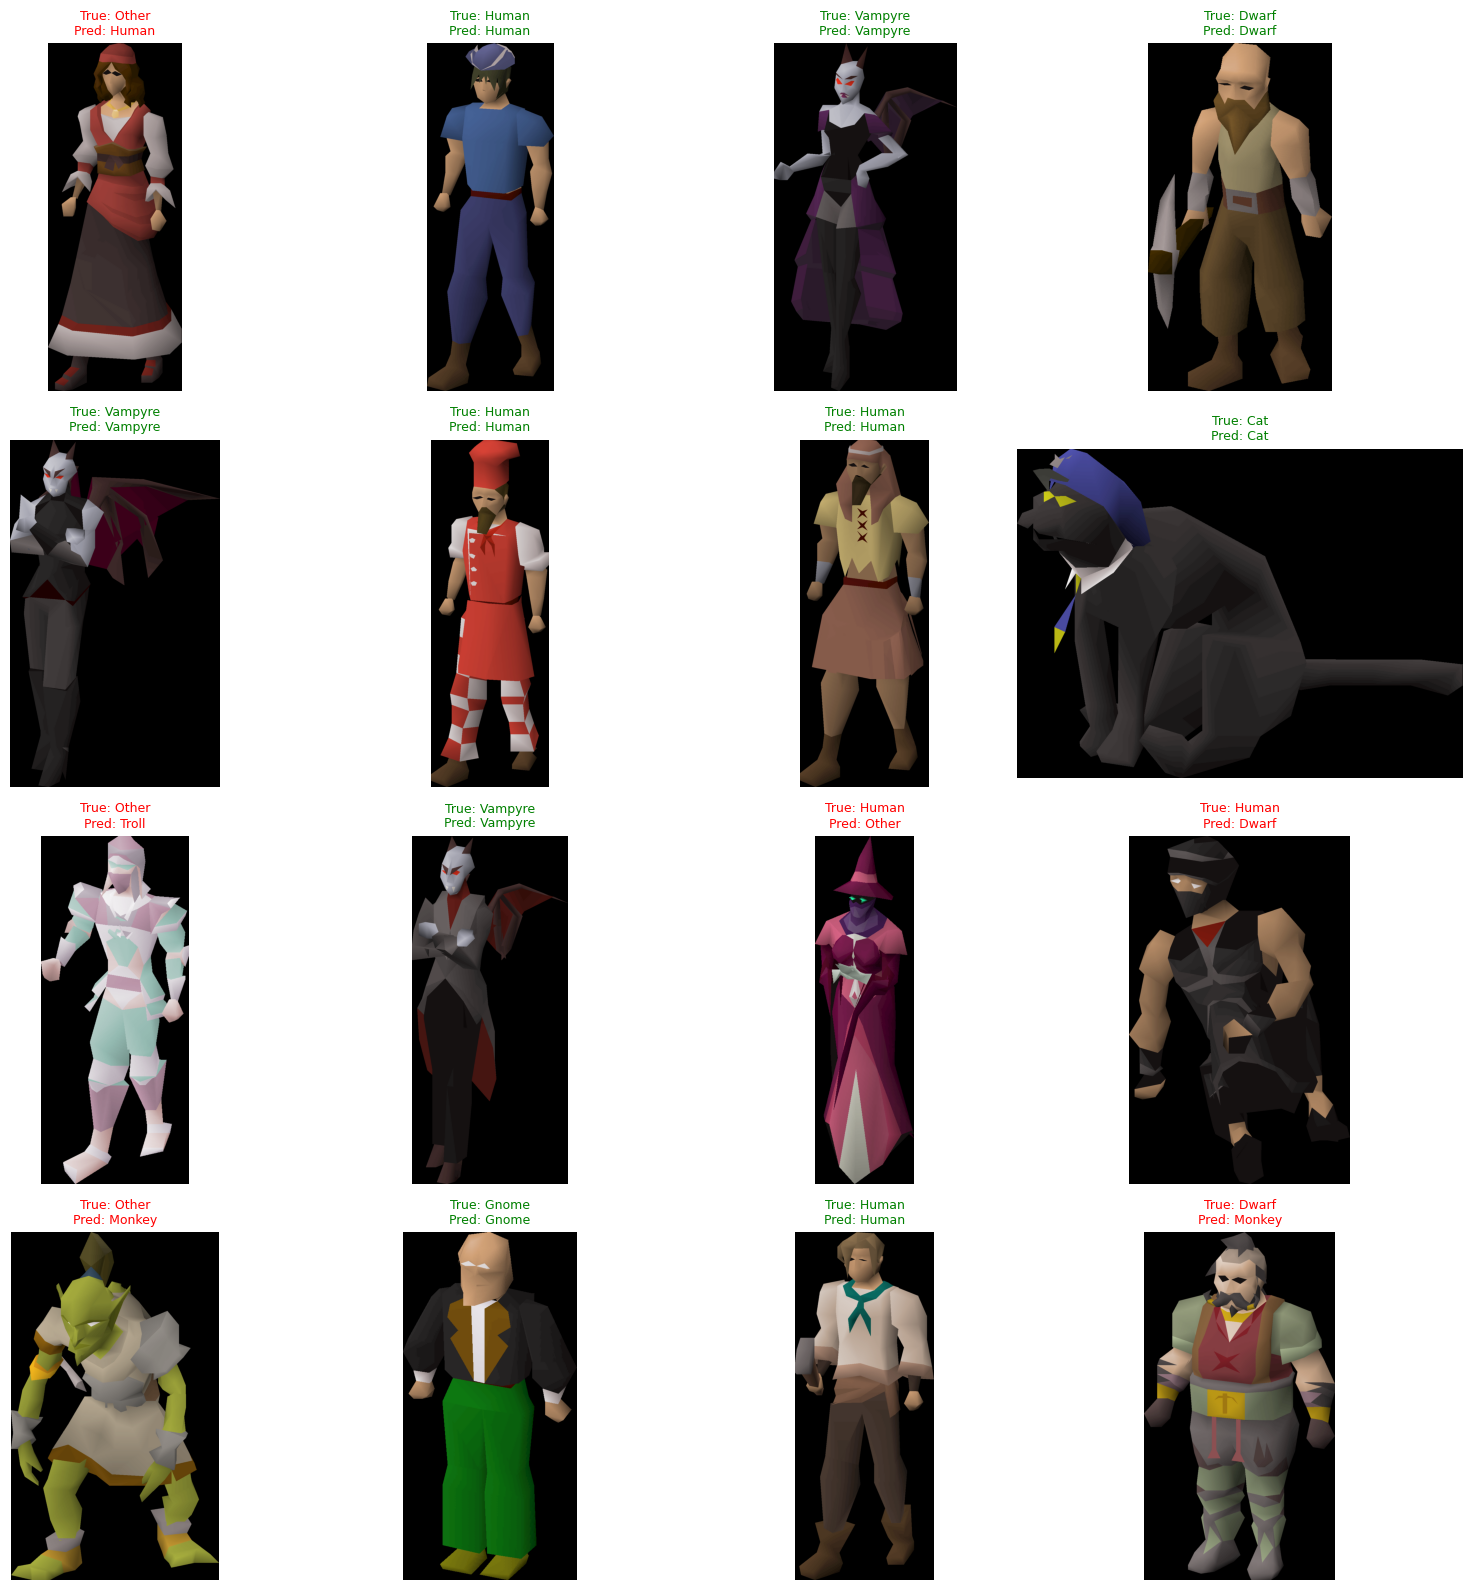

In [6]:
eu.predictions_grid(model, test_df, CLASS_NAMES, eval_transform, "../data", DEVICE, n=16, save_path="../img/challenger_predictions_sample.png")

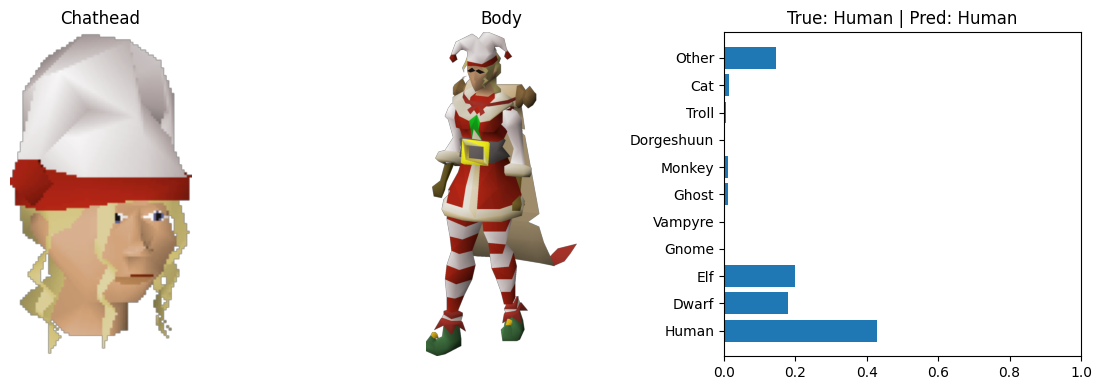

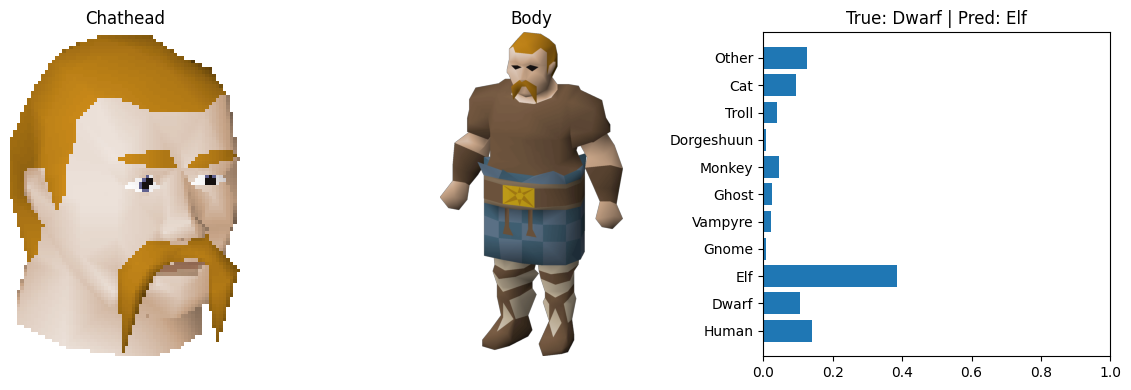

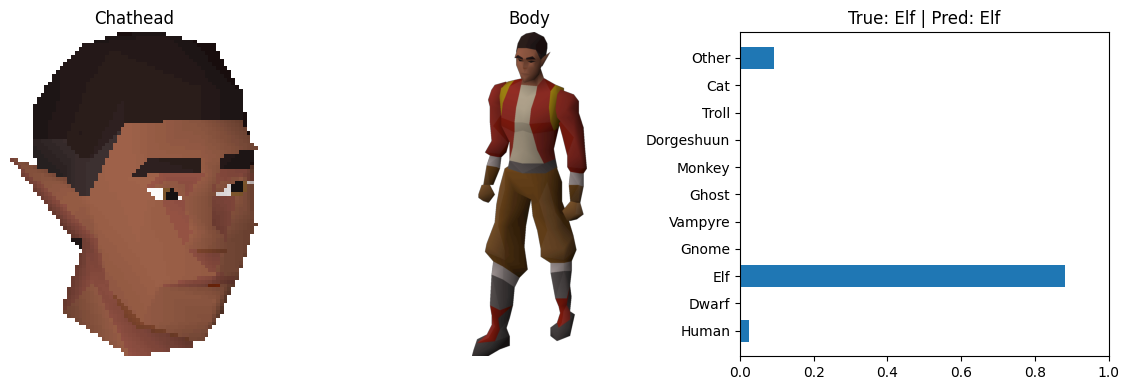

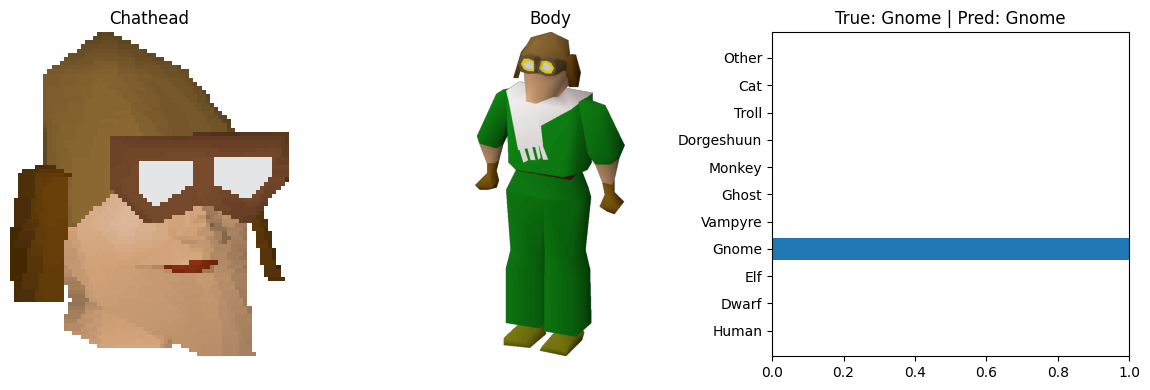

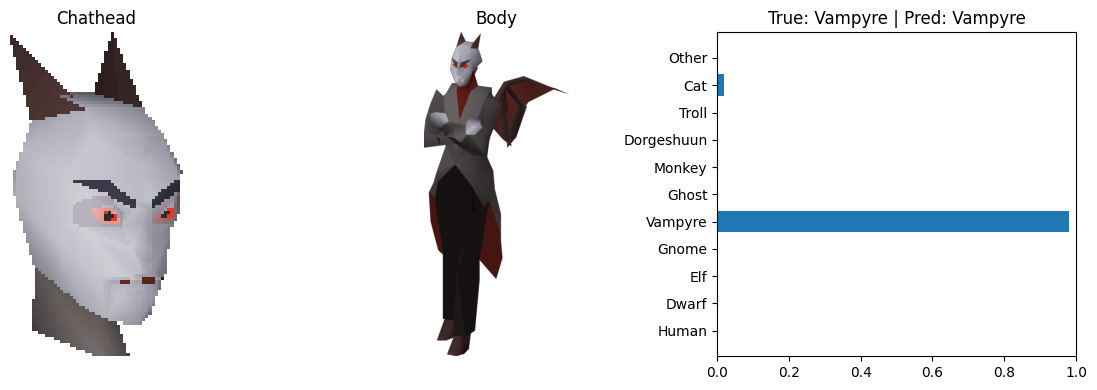

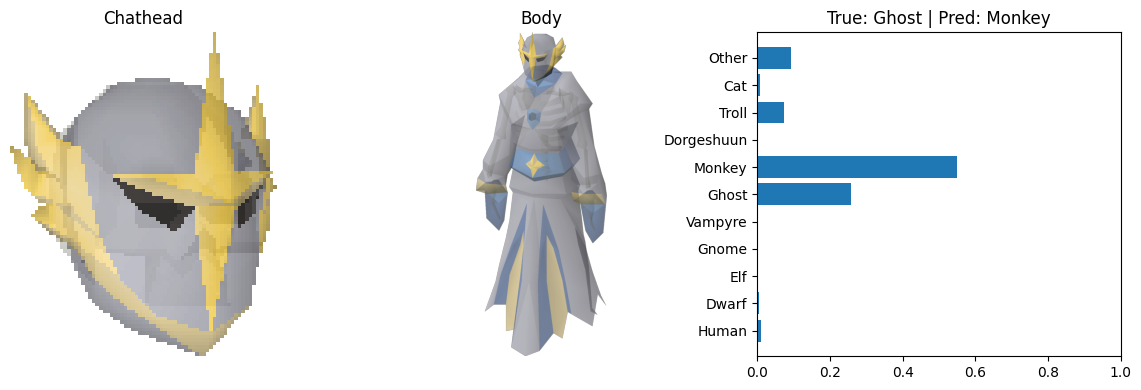

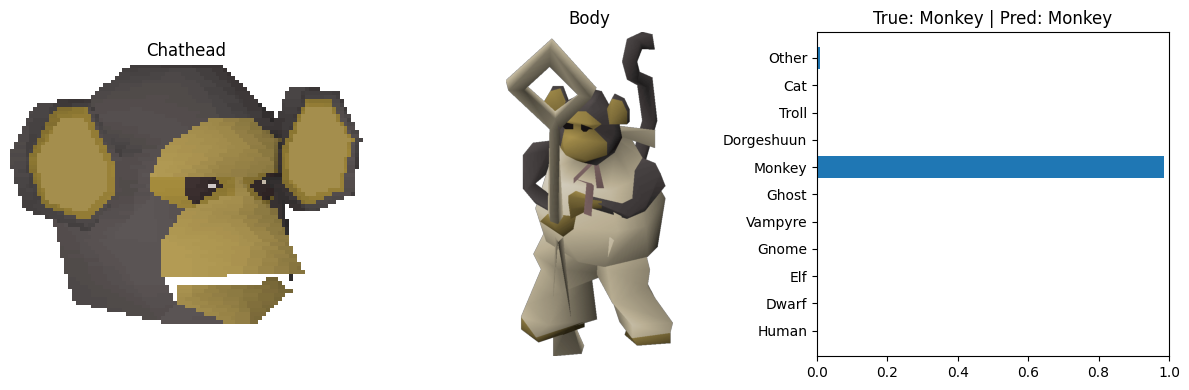

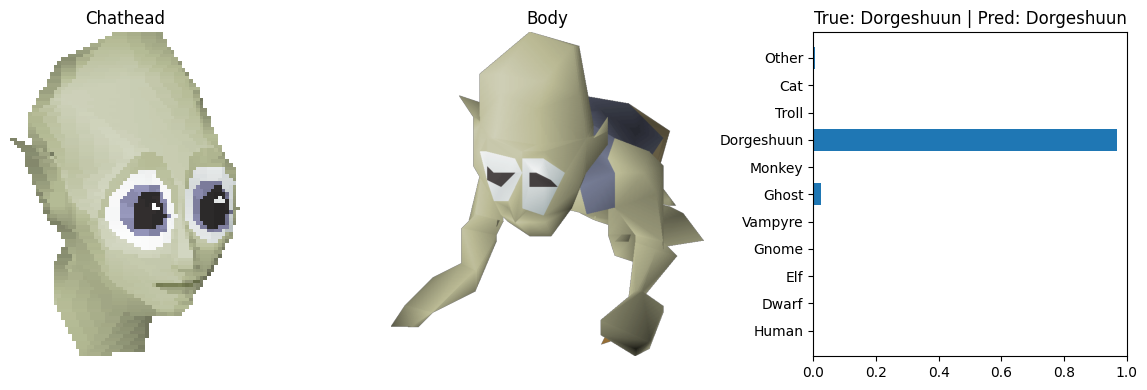

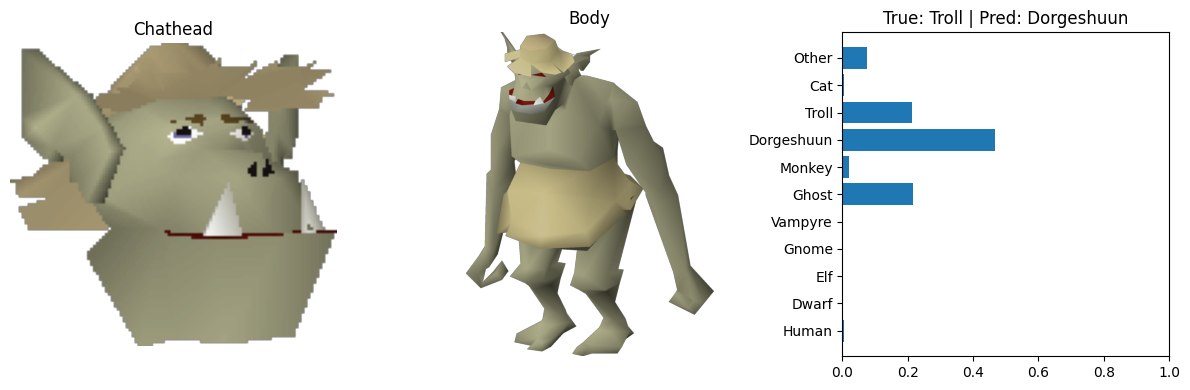

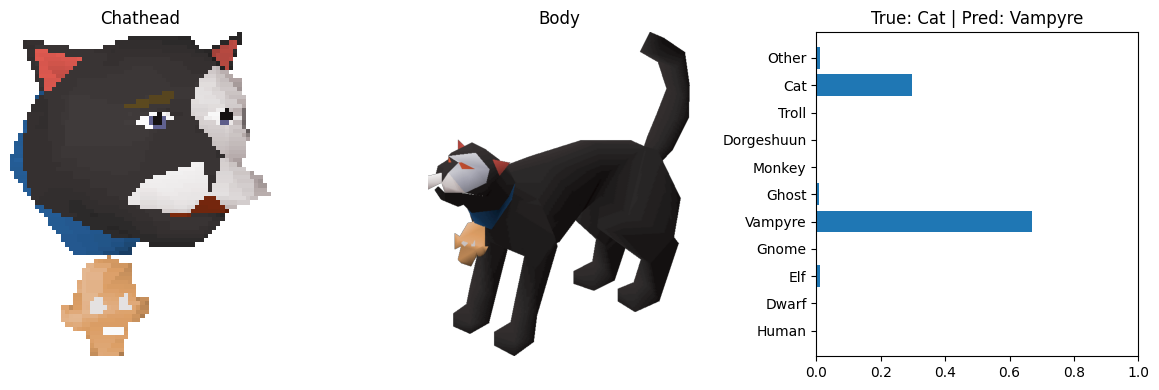

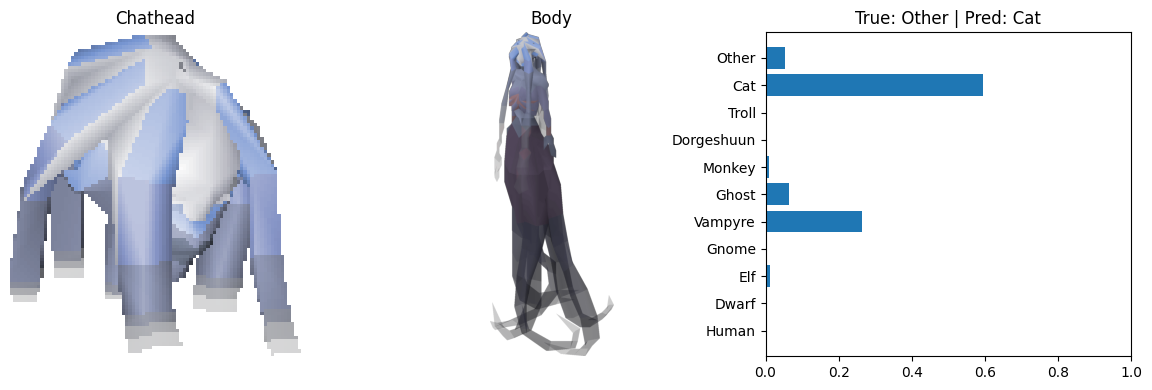

In [7]:
for cls in CLASS_NAMES:
    eu.show_prediction(model, test_df, cls, CLASS_NAMES, eval_transform, "../data", DEVICE)

## Grad-CAM

Same idea as the champion notebook, but targeting the 5 from-scratch conv blocks
(`features[0]` shallow -> `features[4]` deep) instead of ResNet18's named layers.

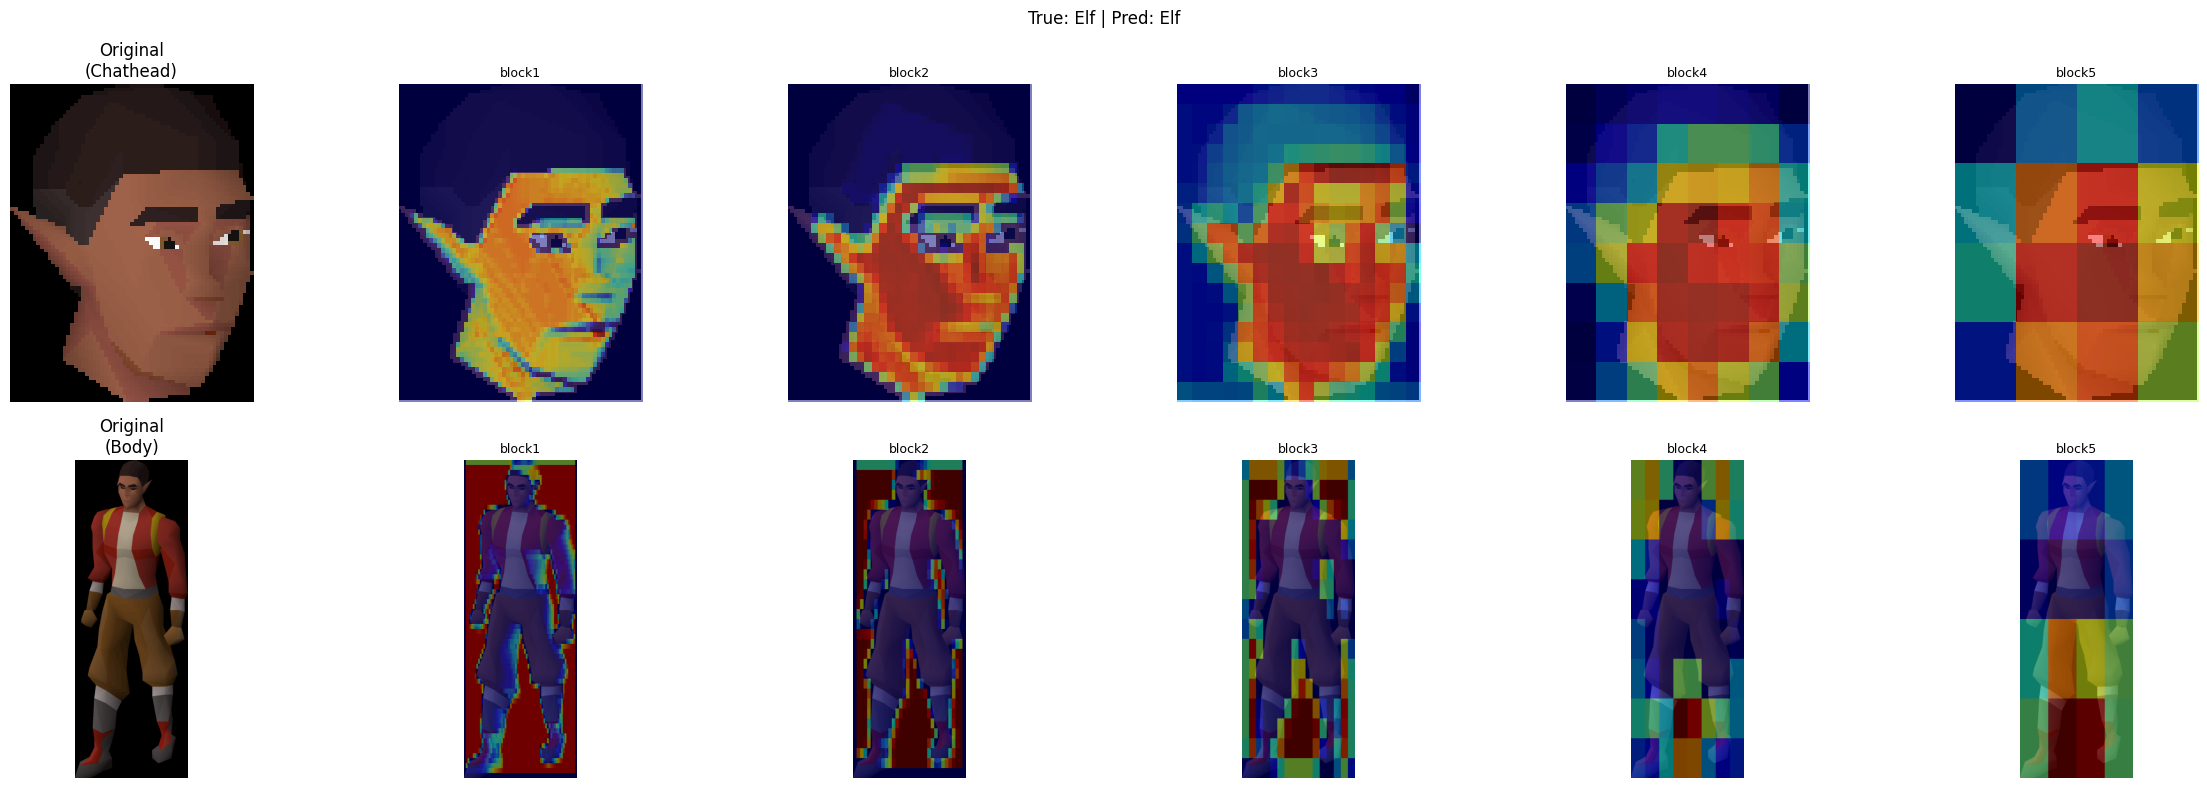

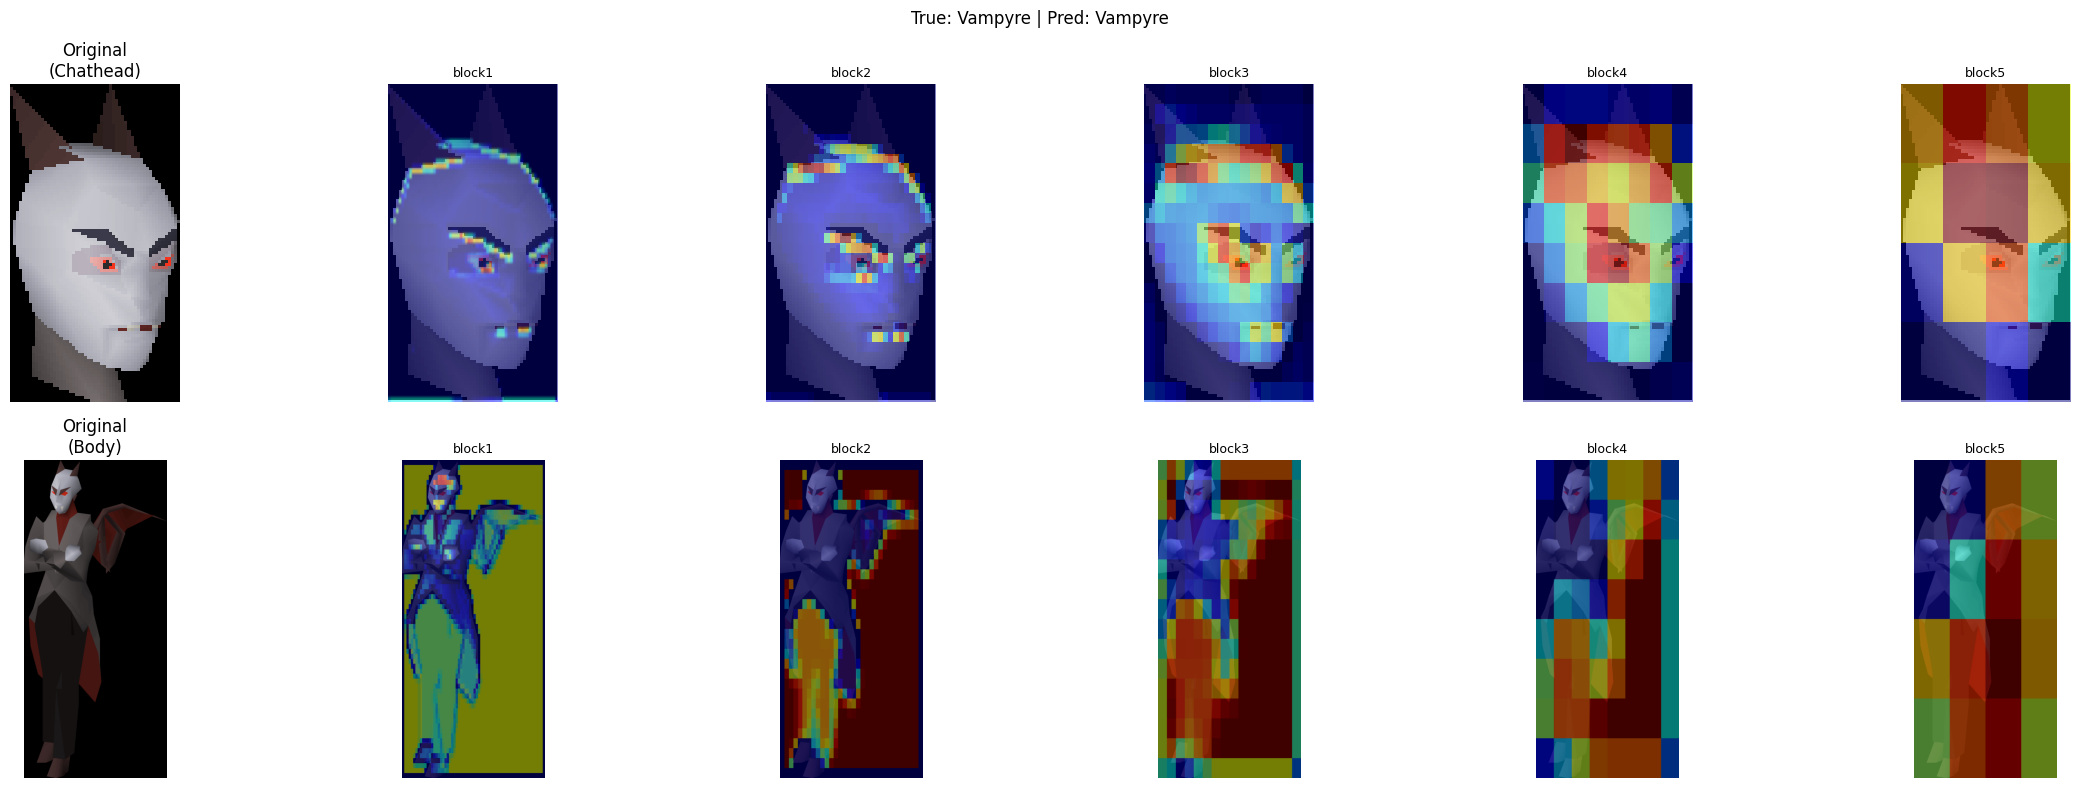

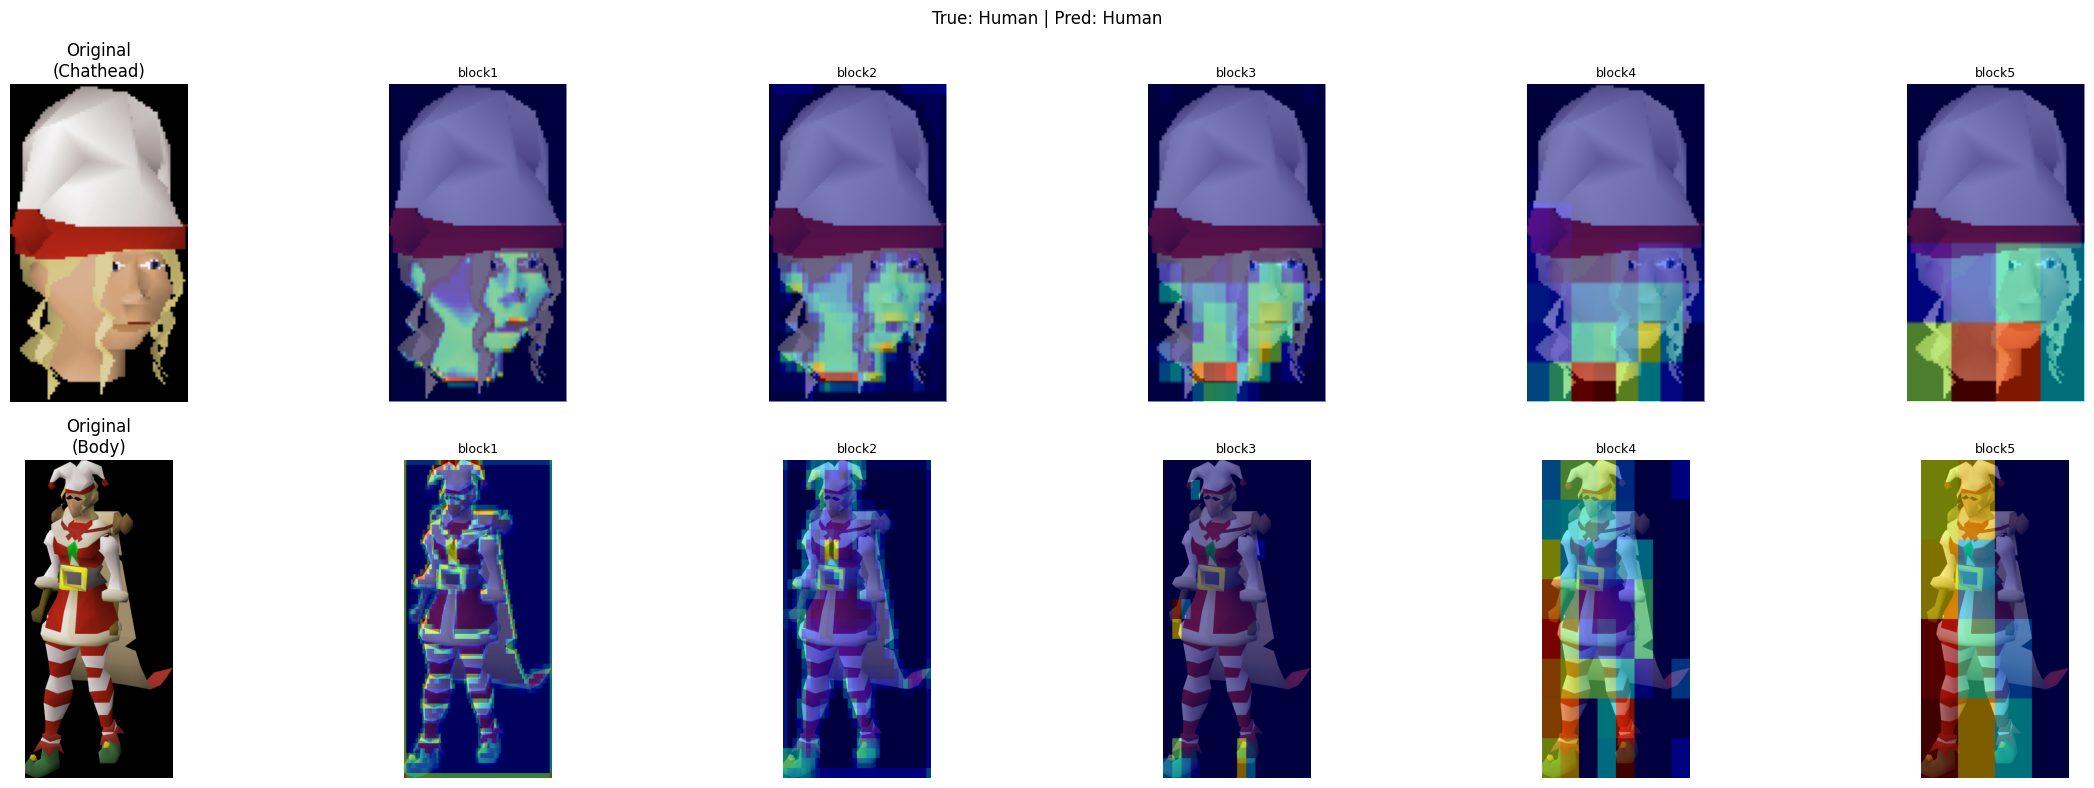

In [8]:
CHATHEAD_LAYERS = [(model.chathead_cnn.features[i], f"block{i+1}") for i in range(5)]
BODY_LAYERS = [(model.body_cnn.features[i], f"block{i+1}") for i in range(5)]

for cls in ["Elf", "Vampyre", "Human"]:
    eu.show_grad_cam(model, test_df, cls, CLASS_NAMES, eval_transform, "../data", DEVICE, CHATHEAD_LAYERS, BODY_LAYERS, seed=42)

## Filter visualization -- first conv block of the body backbone

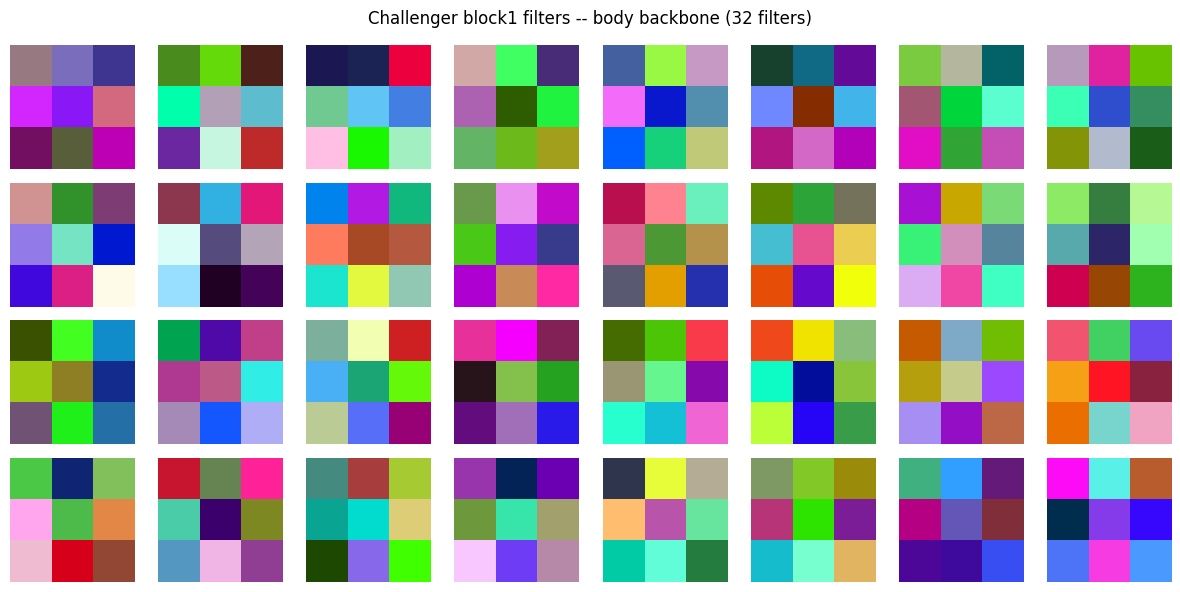

In [9]:
filters = model.body_cnn.features[0][0].weight.detach().cpu()  # first Conv2d in block 1

def normalize_filter(f):
    f = f - f.min()
    return f / (f.max() + 1e-8)

n = filters.shape[0]
fig, axes = plt.subplots(4, n // 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i >= n:
        ax.axis("off")
        continue
    ax.imshow(normalize_filter(filters[i]).permute(1, 2, 0))
    ax.axis("off")
plt.suptitle(f"Challenger block1 filters -- body backbone ({n} filters)", fontsize=12)
plt.tight_layout()
plt.show()

## t-SNE of learned body-branch features (test set)

C:\Users\benja\AppData\Roaming\Python\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


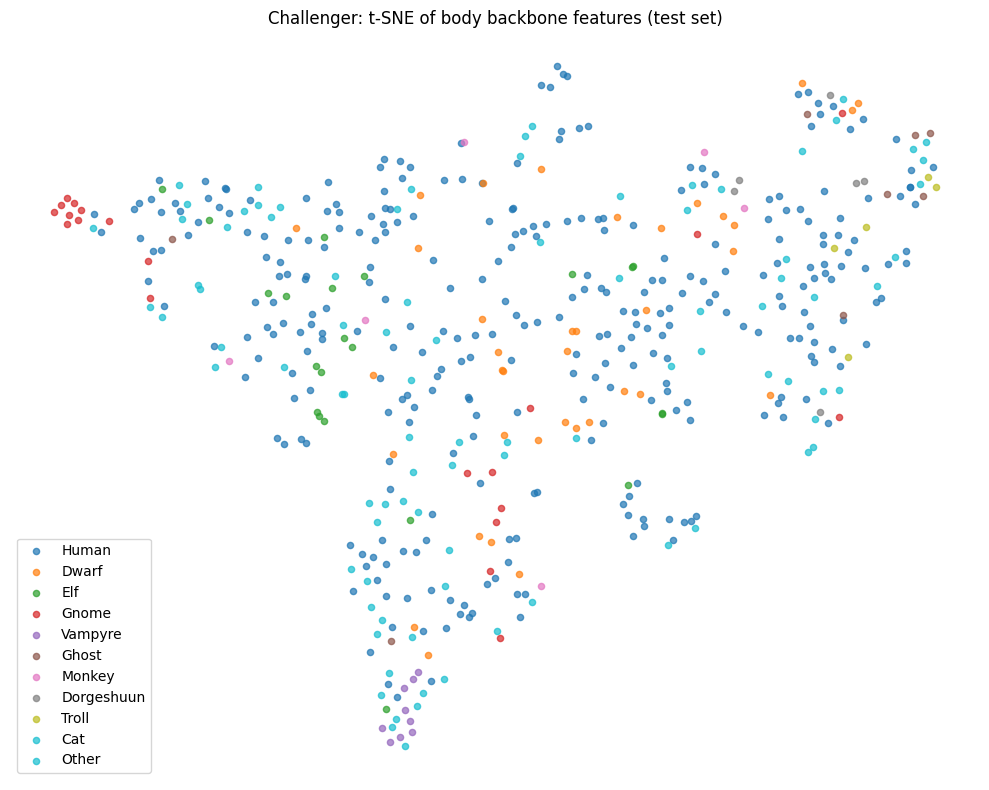

In [10]:
eu.tsne_of_body_features(model, test_loader, DEVICE, CLASS_NAMES, "Challenger: t-SNE of body backbone features (test set)", save_path="../img/challenger_tsne.png")